# Code to train model on recognizing different hand signs.

In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
import os
MAIN_DIR = os.path.dirname(os.path.abspath('__file__'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {DEVICE} device")

Using cuda device


# Dataset Generation

In [3]:
#load data
data_dict = pickle.load(open('data.p', 'rb'))

data = data_dict['data']
labels = data_dict['labels']

In [4]:
print(data[0])

[[0.04978334903717041, 0.24128615856170654], [0.12331533432006836, 0.2207164168357849], [0.18260949850082397, 0.14851850271224976], [0.21922528743743896, 0.09241423010826111], [0.26313644647598267, 0.05980175733566284], [0.13242560625076294, 0.014271259307861328], [0.18464380502700806, 0.05006095767021179], [0.16630595922470093, 0.11232900619506836], [0.1404050588607788, 0.10769400000572205], [0.08542093634605408, 0.0], [0.1427849531173706, 0.05284327268600464], [0.12635523080825806, 0.12346827983856201], [0.10315164923667908, 0.1065792441368103], [0.040636301040649414, 0.01404532790184021], [0.09128063917160034, 0.07075372338294983], [0.0824371874332428, 0.13570111989974976], [0.06434929370880127, 0.11840489506721497], [0.0, 0.040451377630233765], [0.03813478350639343, 0.07411232590675354], [0.04734477400779724, 0.12273311614990234], [0.04037958383560181, 0.1236606240272522]]


In [5]:
class SignDataset(Dataset):
    def __init__(self, data, labels):
        self.data = [torch.tensor(seq, dtype=torch.float32).flatten() for seq in data]
        self.labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    @property
    def classes(self):
        return self.data.classes

In [6]:
dataset = SignDataset(data, labels)
len(dataset)

13741

In [7]:
landmarks, label = dataset[1000]
print(landmarks)
print(label)

tensor([0.0721, 0.3893, 0.1251, 0.3653, 0.1696, 0.3051, 0.1352, 0.2835, 0.0888,
        0.3101, 0.1202, 0.1919, 0.1148, 0.1060, 0.1062, 0.0553, 0.0917, 0.0000,
        0.0715, 0.1885, 0.0903, 0.1995, 0.1046, 0.2692, 0.0967, 0.2698, 0.0328,
        0.2098, 0.0521, 0.2427, 0.0698, 0.2948, 0.0625, 0.2811, 0.0000, 0.2430,
        0.0191, 0.2800, 0.0388, 0.3137, 0.0317, 0.3054])
tensor(10)


In [8]:
#Split train and validation dataset
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])
print(len(train_dataset))
print(len(test_dataset))

10993
2748


# DataLoader Generation

In [9]:
train_dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 64, shuffle = True)

In [10]:
for data, label in train_dataloader:
    break

In [11]:
# 128 datapoints per batch, 21 landmarks [x, y] flatten to become shape 42
# Roughly 10 batches per epoch for training data
print(data.shape)

torch.Size([128, 42])


In [12]:
print(label.shape)

torch.Size([128])


# Neural Network Construction

In [13]:
from neural_net_classes_definition import NeuralNetwork_ver3

In [14]:
model = NeuralNetwork_ver3()
print(model)

NeuralNetwork_ver3(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=29, bias=True)
    (5): LogSoftmax(dim=1)
  )
)


In [15]:
ex_output = model(data)
ex_output.shape # [batch_size, num_classes]

torch.Size([128, 29])

# Loss & Optimizer

In [16]:
#Loss
criterion = nn.CrossEntropyLoss()
#Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [17]:
criterion(ex_output, label)

tensor(3.3709, grad_fn=<NllLossBackward0>)

In [18]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Load Pre-trained Model

In [24]:
def load_checkpoint(filename: str, model: object, optimizer: object) -> (object, object): 
    print("Loading checkpoint")
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    #If save more things, get more from the dict and then return
    return model, optimizer

In [25]:
model, optimizer = load_checkpoint("model_checkpoint_3.pth.rar", model, optimizer)

Loading checkpoint


In [26]:
model

NeuralNetwork_ver3(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=29, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

In [27]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


# Continue Model Training

In [28]:
num_epochs = 400
train_losses, val_losses = [], []

model.to(DEVICE)

for epoch in range(num_epochs):
    model.train() #setting model mode .train or .eval
    running_loss = 0.0
    for landmarks, labels in tqdm(train_dataloader, desc = "Training loop"):
        landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)

    #Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for landmarks, labels in tqdm(test_dataloader, desc = "Validation loop"):
            landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)
            outputs = model(landmarks)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(test_dataloader.dataset)
    val_losses.append(val_loss)

    print("Epoch %d out of %s - Train loss: %s , Validation loss: %s" % (epoch + 1, num_epochs, train_loss, val_loss))

Training loop:   0%|          | 0/108 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 1 out of 400 - Train loss: 0.202121701600397 , Validation loss: 0.1393413386881091


Training loop:   0%|          | 0/108 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/43 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 399 out of 400 - Train loss: 0.004221362875253916 , Validation loss: 0.0029111479302621522


Training loop:   0%|          | 0/108 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 400 out of 400 - Train loss: 0.00418936438120033 , Validation loss: 0.0029196693708379976


# Visualize

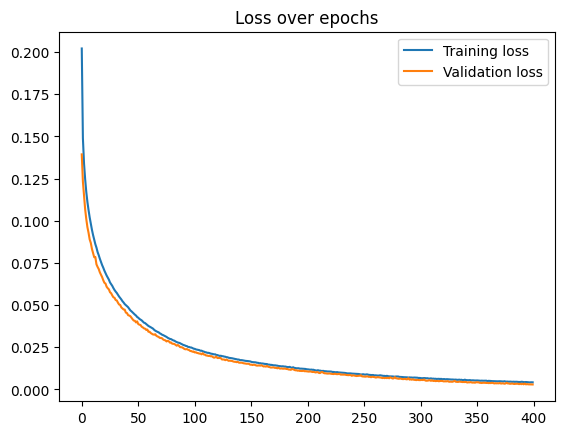

In [29]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Save Model State for Further Training Later

In [30]:
checkpoint = {'state_dict' : model. state_dict(), 'optimizer': optimizer.state_dict()}

In [31]:
def save_checkpoint(state, filename = "model_checkpoint_3_1.pth.rar"):
    print("Saving current checkpoint")
    torch.save(state, filename)

In [32]:
save_checkpoint(checkpoint)

Saving current checkpoint


# Save Model for inferencing

In [35]:
# Save model for model inference
# Save the model's state_dict
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('model_3_1.pth.rar') # Save

# Test Trained model

In [36]:
import mediapipe as mp
import cv2

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.6, max_num_hands = 1)

In [37]:
def predict(model, input_landmarks):
    model.eval()
    with torch.no_grad():
        input_landmarks = torch.tensor(input_landmarks, dtype=torch.float32).flatten()
        input_landmarks = input_landmarks.unsqueeze(0).to(DEVICE)
        predictions_log = model(input_landmarks)
        predictions_prob = torch.exp(predictions_log)
        max_probability_predicted, max_probability_index = torch.max(predictions_prob, dim=1)
    return max_probability_index.item()

In [38]:
def hand_landmarks_detection(path: str) -> list:
    data_aux, x_, y_ = [], [], []

    img = cv2.imread(path)
    # Flip image horizontally to correctly identify left hand being used in the collected images
    #img = cv2.flip(img, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    # Only use the images with left hand for dataset generation => only 21 points for landmarks
    if results.multi_hand_landmarks and results.multi_handedness[0].classification[0].label == 'Left':
        for hand_landmarks in results.multi_hand_landmarks:
            # Write images with overlapped hand landmarks on the original data collected.
            mp_drawing.draw_landmarks(
                img,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,  
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
            
            for i in range(len(hand_landmarks.landmark)):
                x = hand_landmarks.landmark[i].x
                y = hand_landmarks.landmark[i].y

                x_.append(x)
                y_.append(y)

        # To reduce variability for different positions of the hand on the screen, each data point subtracts the lowest x and y position per frame.
        # Essentially reducing the positions of all landmarks to be start at the bottom left conner of the image.
        for i in range(len(hand_landmarks.landmark)):
            x = hand_landmarks.landmark[i].x
            y = hand_landmarks.landmark[i].y
            data_aux.append([x - min(x_), y - min(y_)])
    return data_aux
        

In [39]:
test_folder = "neural_net_model_test_set_after_ver3"
predicted, ground_truth = [], []
for char_folder in os.listdir(test_folder):
    correct_result = char_folder
    for pic in os.listdir(os.path.join(test_folder, char_folder)):
        hand_landmarks = hand_landmarks_detection(os.path.join(test_folder, char_folder, pic))
        if hand_landmarks:
            predicted_result = predict(model, hand_landmarks)
            predicted.append(predicted_result)
            ground_truth.append(int(char_folder))

predicted = torch.tensor(predicted)
ground_truth = torch.tensor(ground_truth)

In [40]:
import torchmetrics
NUM_CLASSES = 29

accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES, average='macro')
precision = torchmetrics.Precision(task='multiclass', num_classes=NUM_CLASSES, average='macro')
recall = torchmetrics.Recall(task='multiclass', num_classes=NUM_CLASSES, average='macro')
f1score = torchmetrics.F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')

accuracy.update(predicted, ground_truth)
precision.update(predicted, ground_truth)
recall.update(predicted, ground_truth)
f1score.update(predicted, ground_truth)

In [41]:
# Compute and print results
print("Accuracy:", accuracy.compute())
print("Precision:", precision.compute())
print("Recall:", recall.compute())
print("F1 Score:", f1score.compute())

Accuracy: tensor(0.9054)
Precision: tensor(0.8948)
Recall: tensor(0.9054)
F1 Score: tensor(0.8944)
